<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week4/titanicClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 이번 학습의 목표는 다음과 같다.
1. Feature Selection (입력 데이터 $X$에 대한 특징 $x_{1}, x_{2}, ... , x_{n}$ 선별)
2. 결측치 확인 & 제거 (특정 $x$에 대해 측정되지 않은 행)
3. Label 개수 확인 (Imbalanced Data인지 확인)
4. Label Encoding (Label이 0,1,2 등의 숫자가 아닌 문자일 때, 숫자로 바꿔줌.)

In [146]:
import pandas as pd
import numpy as np

In [147]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week4/titanic.csv'

df = pd.read_csv(path)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# df 분석
## 각 열(Feature, $x$)의 의미 분석
1. PassengerId: 승객 고유 번호
2. Survived: 생존 여부 (Label로 사용할 특징)
3. Pclass: 객실 등급 (1: 1등석, 2: 2등석, 3: 3등석)
4. Name: 승객 이름
5. Sex: 성별 (male, female)
6. Age: 나이
7. SibSp: 동승한 형제 자매(Sibling)와 배우자(Spouse)의 수
8. Parch: 동승한 부모(Parent)와 자녀(Children)의 수
9. Ticket: 티켓 번호
10. Fare: 요금
11. Cabin: 객실 번호
12. Embarked: 승선 항구, 어디서 탔는가? (S: Southampton, C: Cherbourg, Q: Queenstown)
---
# **Feature Selection**
머신러닝에서는 당연히 **특징($x$)이 많은 것이 더 좋다**. 왜? 특징이 많을 수록 더 정확히 예측할 수 있기 때문이다.
> 예시) 당뇨 체크 할 때
> - $x$가 나이, 성별, 몸무게만 있어 특징이 적으면, 데이터 추세 찾기가 어려움.
> - $x$가 나이, 성별, 몸무게, 혈당, 혈압, 피하지방 등등 특징이 많으면 데이터 추세 찾기가 더 쉬움

근데, 그렇다고 특징이 **무작정 많으면 오히려 성능이 떨어진다!!** 왜일까? <br> **필요없는 특징**이 있으면 오히려 **노이즈**가 되어 **성능이 떨어지기** 때문이다. 이는 이번 df를 통해 알 수 있다.<br>
우리는 현재 Label인 'Survived'에 두고 **어떤 특징을 가진 사람이 생존했는지**를 예측하는 모델을 만들고 있다. 이때 상식적으로 **필요없는 컬럼(특징)** 은 제외해야 한다.
> 예시:
> - PassengerId: 당연히 필요없다. 승객 고유 번호가 생존 여부와 무슨 상관이 있겠는가? 없으니까 **제외**
> - Name: 생존 여부와 이름?? 상관이 없다. **제외**
> - Ticket: 티켓 번호는 그저 티켓 발부 시 식별하는 번호이다. 그러니 생존 여부와 관련이 없다. **제외**
> - Embarked: 어느 항구에서 탔는지이다. 난 이거를 제외할 거라고 생각했지만, 챗지피티는 달랐다. **포함**해야 한다고 한다. 왜일까?<br>탑승 항구마다 **어떤 특성의 사람들이 탔는지**가 나오기 때문이다. 귀족들이 많이 타는 항구, 평민들이 많이 타는 항구 등의 차이가 존재하기 때문이다. 그래서 **Embarked는 포함이다!**
>    - 실제 탑승 항구별 생존률을 보면 알 수 있다.
>         - C: 약 55.4%
>         - Q: 약 39.0%
>         - S: 약 33.7%

**→ `X = df.drop(['Label', '제거할 열이름1', ...], axis=1)` 를 이용해 필요없는 열을 제거하고 필요한 특징만 선별한다.**

---
# **결측치 확인 및 제거**
앞에서 생존 여부와 필요없는 열(특징)들을 제거했다. 이제, **결측치 제거**를 해보자.
- 결측치가 뭔데? **결측치(Missing Value)** 란, 데이터 수집 과정에서 누락되거나 측정되지 않은 **빈** 값이다.
- 이런 결측치가 남아있으면, 모델을 위한 **API**에서 이 결측치를 **NaN**로 표시된다.그래서, 머신러닝 모델은 이런 결측치가 남아있으면, **에러가 나거나 성능이 떨어진다**.

그래서, 이런 결측치가 발견되면, **결측치를 제거**한다. 이때, 제거의 방법으로는 3가지가 있다.
1. 결측치가 있는 행 제거: 깔끔하지만 **위험**하다. 머신러닝은 데이터가 많을 수록 좋은데, 해당 데이터를 삭제하는 것이기 때문이다.<br>예를 들면, 1000개의 데이터 중 300개가 결측치가 있다고 해서 300개를 없애면 안 그래도 적은 데이터에서 데이터를 더 빼버리는 현상이 나온다.
2. 열(특징)을 삭제: 이것도 깔끔하지만 **위험**하다. 머신러닝은 특징이 많을 수록 좋기 때문이다.<br>하지만, 해당 열에 대한 결측치 데이터가 너무 많은 경우에는 있으나 마나 이기에 제거한다. → **결측치가 너무 많은 컬럼은 아예 제거**
3. 결측치에 **값을 채워서** 제거: 가장 많이 사용한다!!<br> 주로 데이터의 **평균값이나 중앙값이나 최빈값**을 넣어 데이터가 줄어드는 것을 막는다.

> df로 예시를 들면, 다음과 같다.
> - Cabin: 객실 번호라, 해당 객실의 등급에 따라 생존 여부에 넣을 수 있을 것 같지만, 해당 df에는 Cabin 열에 대해 **결측치가 너무 많다(무려 687개)**. 결측치가 많은 특징은 **무의미하므로 제거**
> - Age: 결측치가 꽤 많지만(177개), **생존 여부와 너무 관련이 높아서** 버리기 아쉽다. 그러니, 결측치를 다른 값으로 **대체**해야 한다.
>   - 평균: 평균의 문제점은 **특정값이 너무 크거나 작으면 값이 너무 크게 변해 대표 대체값으로 두기 애매하다.** 나이도 마찬가지이다.(예: 특정 사람의 나이가 101세 또는 영유아(0세)면... 평균이 너무 커지거나 작아져 대표하기에는 문제가 생긴다.)
>   - 중앙값: 그래서 주로 나이는 **중앙값**을 가장 많이 사용한다.
>
> - Embarked: 2개로 매우 적다. 그렇기 때문에 **대체**하는 것이 좋다. (2개의 데이터도 중요하다.) 사람들이 가장 많이 탄 곳이 제일 유력하므로 **최빈값**으로 채운다.

**→ `df.isnull().sum()`를 사용해서 어떤 열에 결측치가 몇 개 있는지 확인할 수 있다. 그리고, `df = df.dropna()` 를 이용해서 결측치가 하나라도 있는 데이터(행, Row)를 제거한다.(그래서 잘 사용하지 않는 방법이다.)**

Survived
0    549
1    342
Name: count, dtype: int64


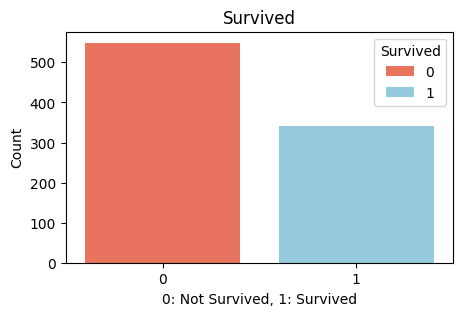

In [148]:
y=df['Survived']
# 숫자로 레이블 개수 확인
print(y.value_counts())

# 그래프로 레이블 개수 확인
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
sns.countplot(data = df, x="Survived", hue="Survived", palette=["tomato", "skyblue"])
plt.xlabel("0: Not Survived, 1: Survived")
plt.ylabel("Count")
plt.title("Survived")
plt.show()

# **Label 개수 확인**
위 코드에서 `print(.value_counts())` 부분이다.<br>
한쪽 클래스가 너무 많은지 확인하는 용도이다. 즉, **Imbalanced Data**인지 아닌지 확인하는 용도이다.

**→ 위처럼 `print(.value_counts())`를 사용하거나,**
```python
sns.countplot(data = df, x="label")
plt.xlabel("Cancer or Not")
plt.ylabel("Count")
plt.title("Label")
```
**를 이용한다.**

---
**Imbalanced Data**이면, **측정된 Accurancy를 믿지 못하기 때문**이다.<br>
하지만, 어쩔 수 없이 데이터가 Imbalanced 할 때가 존재한다. 이때는 **F1 Score**를 이용한다.

In [149]:
# 필요없는 노이즈 컬럼(Feature) 제거
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S


In [150]:
# 결측치 확인
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


## **.fillna()** 메소드
이건 df의 NaN인 결측치를 ()안의 매개변수 값으로 채우는 메소드이다.
- `X['Age'] = X['Age'].fillna(X['Age'].median())` : <br>`X`라는 df의 `Age` 컬럼의 `NaN`을 해당 열의 중앙값(`.median()`)으로 채운다.
- `X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])` : <br>`X`라는 df의 `Embarked` 컬럼의 `NaN`을 해당 열의 최빈값(`.mode()`)으로 채운다.<br>(이때, `mode()[0]` 인 이유는 [1, 1, 2, 2, 3] 라고 했을 때, 최빈값이 [1,2]로 2개가 나오므로 그 중 하나의 값을 고르기 위해 [0]을 적은 것이다.)

In [151]:
# 결측치 제거
X['Age'] = X['Age'].fillna(X['Age'].median()) # Age는 중앙값으로 대체
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0]) # Embarked는 최빈값으로 대체
X = X.drop('Cabin', axis=1) # Cabin은 너무 많으므로 열 자체를 제거

X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# **Label Encoding**
근데, 이 상태로 Train, Test를 나누고 fit으로 학습을 하면, 다음과 같은 에러 메시지와 함께 **문제**가 생긴다!
> ValueError: could not convert string to float: 'Mionoff, Mr. Stoytcho'

왜 그럴까? 이유는 에러 메시지를 보면 알겠지만, **문자열**이기 때문이다.(Sex, Embarked 컬럼들이 문자열!)<br>
그러면, 어떻게 해야 할까? 여기서 **Label Encoding**이 필요하다.
- Sex: **male은 0, female은 1로 매핑**시켜 바꾸면 깔끔하다.(어처피, 남자/여자 이므로 각각 0,1로 매핑 시켜도 문제가 없다.
- Embarked: 일단, 난 이것도 S, C, Q를 각각 0, 1, 2로 하자 라고 했지만, 오.. 챗지피티는 또 아니라고 한다... 챗지피티는 **One-Hot Encoding**을 추천한다.
> One-Hot Encoding이란?<br>
> **범주형 데이터**(성별, 지역, 종류 등 **수치로 측정할 수 없는 데이터**)에서 사용하는 Encoding 방식으로 모델이 데이터를 학습할 때 데이터 간 아무런 연관이 없으나 숫자로 매핑 시켜 생기는 **데이터 연속성**으로 인해 생기는 **오해**를 막기 위한 방식이다.<br>(위의 성별인 경우 어처피 2개이므로, (0/1)로 나눠도 one-hot과 같은 효과를 내기 때문에 문제가 없음.)<br>(관련 링크: https://m.blog.naver.com/baek2sm/221802541443)

In [152]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Sex는 Label Encoder를 이용해 문자열을 숫자로 바꾼다.
X['Sex'] = le.fit_transform(X['Sex'])

# pandas의 get_dummies()를 이용해 One-Hot Encoding을 진행한다.
X = pd.get_dummies(X, columns=['Embarked'], drop_first=True, dtype=int)

X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,0,1
1,1,0,38.0,1,0,71.2833,0,0
2,3,0,26.0,0,0,7.9250,0,1
3,1,0,35.0,1,0,53.1000,0,1
4,3,1,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,0,1
887,1,0,19.0,0,0,30.0000,0,1
888,3,0,28.0,1,2,23.4500,0,1
889,1,1,26.0,0,0,30.0000,0,0


# 위 코드 설명

## LabelEncoder() 와 le.fit_transform()

- `LabelEncoder`는 `scikit-learn` 라이브러리의 `preprocessing` 모듈에서 가져온 도구이다.
- 변수 `le`에 `LabelEncoder` 객체를 저장한다.
- `le.fit_transform()`은 `fit`으로 데이터(`Sex` 열)를 보고 학습하여 `female: 0`, `male: 1`로 정한 뒤, `transform`으로 각각 매핑시키는 작업을 한 번에 수행한 것이다.

  ```python
  le.fit(X['Sex'])
  le.transform(X['Sex'])
  ```
- 즉, 위 두 줄을 한 번에 수행한 것이 le.fit_transform(X['Sex'])이다.
- 보통 다음과 같이 사용한다.
  ```python
  le.fit_transform(df['인코딩할 컬럼명'])
  ```
## **get_dummies()**
- `get_dummies()`는 `pandas` 라이브러리에서 더미 변수(dummy variable)를 만드는 메소드이다.
- 더미 변수는 범주 하나를 `0/1`로 표시한 변수이다.
  - 현재 `Embarked`를 통해 예시를 들면,
  | Embarked | Embarked_C | Embarked_Q | Embarked_S |
| -------- | ---------: | ---------: | ---------: |
| C        |          1 |          0 |          0 |
| Q        |          0 |          1 |          0 |
| S        |          0 |          0 |          1 |

    즉, 각 범주를 “해당하면 1, 아니면 0”인 컬럼으로 분해한 것이 **더미 변수**이다.
- 보통 다음과 같이 사용한다.
  ```python
  pd.get_dummies(df, columns=['범주형 컬럼명'], drop_first=True, dtype=int)
  ```
  - 여기서 drop_first=True는 첫 번째 범주를 하나 빼라는 뜻이다.
  - 위 코드에서는 Embarked_C가 빠진다.
  
  왜 하나를 뺄까?
  -빠진 범주 하나를 **기준 범주(Reference Category)** 로 사용하기 위해서이다.

  위 코드에서는 C가 기준 범주이므로, 다음과 같이 해석할 수 있다.
  | Embarked_Q | Embarked_S | 실제 의미 |
  | ---------: | ---------: | ----- |
  |          0 |          0 | C     |
  |          1 |          0 | Q     |
  |          0 |          1 | S     |

  > ### 근데, 왜 굳이 **하나를** 기준 범주로 만들어서 **뺄까??** 위 코드를 예시로 알아보자.
  > - `Embarked = C, Q, S` 이다. 이를 One-Hot으로 전부 만들면,
  > - `Embarked_C`
  > - `Embarked_Q`
  > - `Embarked_S`
  >
  > 이렇게 3개가 생긴다. <br>
  > 그런데, 이 셋은 항상 합이 **1**이다.
  > - C면 (1,0,0)
  > - Q면 (0,1,0)
  > - S면 (0,0,1)
  >
  > 즉, **하나를 알면 나머지 하나도 자동으로 결정된다.**<br>
  > 이런 상태를 선형/로지스틱 회귀에서는 완전한 중복 정보로 보고, 이를 **Dummy Variable Trap** 또는 **완전 다중공선성** 문제라고 한다.
  > - **완전 다중공선성(perfect multicollinearity)**: 한 컬럼이 다른 컬럼들로 **완전히 표현 가능**한 상태
  >
  > 이 **다중공선성 상태는 선형 모델에서는 안 좋다.**<br>
  > 그 이유는
  > 1. 정보의 **중복**<br>
  > 2개만 있으면 나머지 1개는 자동으로 알 수 있으므로, **불필요한 중복이 생김.**
  >
  > 2. 회귀계수 해석이 꼬임<br>
  >로지스틱 회귀는 각 feature에 대한 계수를 학습하는데, 컬럼들이 완전히 종속돼 있으면 **어떤 컬럼 효과를 얼마나 줄지, 기준을 어디에 둘지**가 애매해진다. 즉, **계수가 불안정**해질 수 있다.
  >
  > 3. 어떤 모델/구현에서는 계산 문제가 생길 수 있음 <br> 완전 다중공선성이 있으면 **행렬이 역행렬을 못 가지거나 수치적으로 불안정**해질 수 있다.
  >
  > ▶그래서, one-hot 할 때는 보통 **범주가 k개면 k-1개만 남기기 위해** `drop_first=True`를 쓴다.

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [154]:
# Logistic Regression 방식

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_lr = LogisticRegression(random_state=0, max_iter=1000)
clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
lr_accuracy = accuracy_score(y_test, pred_lr)
print (lr_accuracy)
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7937219730941704
[[116  23]
 [ 23  61]]


In [155]:
# Decision Tree 방식
from sklearn.tree import DecisionTreeClassifier # 여기 부분이 다르다!!
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print("\n--- Decision Tree Classifier ---")
dt_accuracy = accuracy_score(y_test, pred_dt)
print(dt_accuracy)
print(confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
0.7937219730941704
[[120  19]
 [ 27  57]]


In [156]:
# Random Forest 방식
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X_train, y_train)

pred_rf = clf_rf.predict(X_test)

print("\n--- Random Forest Classifier ---")
rf_accuracy = accuracy_score(y_test, pred_rf)
print(rf_accuracy)
print(confusion_matrix(y_test, pred_rf))


--- Random Forest Classifier ---
0.8340807174887892
[[123  16]
 [ 21  63]]


In [157]:
# kNN(k-Nearest Neighbor) 방식
from sklearn.neighbors import KNeighborsClassifier # 여기 부분이 다르다!!
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

knn = KNeighborsClassifier(n_neighbors=6) # 가까운 이웃(데이터) 6개를 봐라!
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("\n--- k-Nearest Neighbor Classifier ---")
knn_accuracy = accuracy_score(y_test, pred_knn)
print(knn_accuracy)
print(confusion_matrix(y_test, pred_knn))


--- k-Nearest Neighbor Classifier ---
0.7354260089686099
[[126  13]
 [ 46  38]]


# 그렇다면, 이제 필요없어서 뺀 Feature들을 넣고 성능이 정말 안 좋아지는지 확인 해보자.
- **PassengerId**를 빼지 않고 넣어보았다.

In [158]:
avg_accuracyA = (lr_accuracy + dt_accuracy + rf_accuracy + knn_accuracy)/4
print(avg_accuracyA)

0.7892376681614349


In [159]:
y2 = df['Survived']
# 숫자로 레이블 개수 확인
print(y2.value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [160]:
X2 = df.drop(['Survived', 'Name', 'Ticket'], axis=1)

X2.isnull().sum()

,0
PassengerId,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [161]:
# 결측치 제거
X2['Age'] = X2['Age'].fillna(X2['Age'].median()) # Age는 중앙값으로 대체
X2['Embarked'] = X2['Embarked'].fillna(X2['Embarked'].mode()[0]) # Embarked는 최빈값으로 대체
X2 = X2.drop('Cabin', axis=1) # Cabin은 너무 많으므로 열 자체를 제거

X2.isnull().sum()

,0
PassengerId,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [162]:
X2.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,male,22.0,1,0,7.2500,S
1,2,1,female,38.0,1,0,71.2833,C
2,3,3,female,26.0,0,0,7.9250,S
3,4,1,female,35.0,1,0,53.1000,S
4,5,3,male,35.0,0,0,8.0500,S


In [163]:
# 레이블 인코딩
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Sex는 Label Encoder를 이용해 문자열을 숫자로 바꾼다.
X2['Sex'] = le.fit_transform(X2['Sex'])

# pandas의 get_dummies()를 이용해 One-Hot Encoding을 진행한다.
X2 = pd.get_dummies(X2, columns=['Embarked'], drop_first=True, dtype=int)
X2.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,1,3,1,22.0,1,0,7.2500,0,1
1,2,1,0,38.0,1,0,71.2833,0,0
2,3,3,0,26.0,0,0,7.9250,0,1
3,4,1,0,35.0,1,0,53.1000,0,1
4,5,3,1,35.0,0,0,8.0500,0,1


In [164]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2,test_size=0.25,random_state=0)

In [165]:
# Logistic Regression 방식

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_lr = LogisticRegression(random_state=0, max_iter=1000)
clf_lr.fit(X2_train, y2_train)

pred_lr = clf_lr.predict(X2_test)

print ("\n--- Logistic Regression Classifier ---")
lr_accuracyB = accuracy_score(y2_test, pred_lr)
print (lr_accuracyB)
print (confusion_matrix(y2_test, pred_lr))

# Decision Tree 방식
from sklearn.tree import DecisionTreeClassifier # 여기 부분이 다르다!!
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X2_train, y2_train)

pred_dt = clf_dt.predict(X2_test)

print("\n--- Decision Tree Classifier ---")
dt_accuracyB = accuracy_score(y2_test, pred_dt)
print(dt_accuracyB)
print(confusion_matrix(y2_test, pred_dt))

# Random Forest 방식
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X2_train, y2_train)

pred_rf = clf_rf.predict(X2_test)

print("\n--- Random Forest Classifier ---")
rf_accuracyB = accuracy_score(y2_test, pred_rf)
print(rf_accuracyB)
print(confusion_matrix(y2_test, pred_rf))

# kNN(k-Nearest Neighbor) 방식
from sklearn.neighbors import KNeighborsClassifier # 여기 부분이 다르다!!
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

knn = KNeighborsClassifier(n_neighbors=6) # 가까운 이웃(데이터) 6개를 봐라!
knn.fit(X2_train, y2_train)

pred_knn = knn.predict(X2_test)

print("\n--- k-Nearest Neighbor Classifier ---")
knn_accuracyB = accuracy_score(y2_test, pred_knn)
print(knn_accuracyB)
print(confusion_matrix(y2_test, pred_knn))


--- Logistic Regression Classifier ---
0.7937219730941704
[[116  23]
 [ 23  61]]

--- Decision Tree Classifier ---
0.7757847533632287
[[111  28]
 [ 22  62]]

--- Random Forest Classifier ---
0.8385650224215246
[[126  13]
 [ 23  61]]

--- k-Nearest Neighbor Classifier ---
0.6502242152466368
[[121  18]
 [ 60  24]]


In [166]:
avg_accuracyB = (lr_accuracyB + dt_accuracyB + rf_accuracyB + knn_accuracyB)/4
print(avg_accuracyB)
print(avg_accuracyA - avg_accuracyB)

0.7645739910313901
0.024663677130044803


생각보다 PassengerId는 그리 큰 노이즈를 주지 않는다.
그래도 어느 정도 성능이 낮아진다.